# Binder Design Pipeline — Course 27666

```
RFD3  →  ProteinMPNN  →  RF3
```

Design *de novo* protein binders against a target, then validate them in silico.
Three stages:

1. **RFD3 (RFdiffusion3)** — generate binder *backbones* by diffusion, steered toward
   target hotspot residues.
2. **ProteinMPNN** — design amino-acid *sequences* onto each backbone.
3. **RF3 (RoseTTAFold3)** — *fold & score* each binder+target complex to estimate how
   confident and well-defined the predicted interface is.

The worked example targets the **MMP9** catalytic domain (bundled in `inputs/`).
Everything runs on the GPU cluster via the **`c27666`** LSF queue.

## How to run this notebook

**Read `README.md` first** for full setup. In short:

1. Clone this repo into *your* scratch space: `cd /work3/$USER && git clone <repo-url>`
2. Register the shared conda env as a Jupyter kernel once (see README), select it.
3. Run the cells top to bottom. GPU stages **don't run in the notebook** — each writes an
   LSF submit script and prints a `bsub < ...` command. You run that in a terminal, wait
   for the job to finish (`bstat`), then continue with the next cell.

**Queue notes (`c27666`):** shared by the whole class on only a couple of GPUs, so keep
the design counts small (defaults below are deliberately tiny). Max wall time is 12 h and
the queue default is 15 min — the submit scripts always set `-W 12:00`.

## Setup: imports, repo paths, working directories

In [1]:
# --- Core ---
import os, sys, re, glob, json, math, shutil, csv
from pathlib import Path
from copy import deepcopy

# --- Data / plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Locate the repo root (the folder containing this notebook) ---
# Jupyter starts in the notebook's directory, so cwd is the repo root.
REPO_ROOT = Path.cwd()
if not ((REPO_ROOT / "inputs").is_dir() and (REPO_ROOT / "lib").is_dir()):
    raise RuntimeError(
        f"cwd={REPO_ROOT} is not the repo root (no inputs/ and lib/).\n"
        "Set it manually, e.g.:  REPO_ROOT = Path('/work3/' + os.environ['USER'] + '/binder-design-course')"
    )

# Make the bundled helper modules importable
sys.path.insert(0, str(REPO_ROOT / "lib"))
import jupyter_utils
from rf3_metrics import gather_rf3_metrics

print("Repo root:", REPO_ROOT)
print("User:", os.environ.get("USER", "?"))

Repo root: /dtu/blackhole/0e/213806/group_project
User: s243275


In [2]:
# All run outputs go under work/<experiment>/ inside your clone (git-ignored).
experiment = "exp_04"          # bump this for each new design round
WORK = REPO_ROOT / "work" / experiment

_subdirs = ["cmds", "submit", "logs", "configs", "scores",
            "diffusion_out", "mpnn_out", "rf3_out", "best_binders"]
for d in _subdirs:
    (WORK / d).mkdir(parents=True, exist_ok=True)

cmds_dir          = str(WORK / "cmds")
submit_dir        = str(WORK / "submit")
logs_dir          = str(WORK / "logs")
configs_dir       = str(WORK / "configs")
scores_dir        = str(WORK / "scores")
diffusion_out_dir = str(WORK / "diffusion_out")
mpnn_out_dir      = str(WORK / "mpnn_out")
rf3_out_dir       = str(WORK / "rf3_out")
best_binders_dir  = str(WORK / "best_binders")

pd.set_option("display.max_columns", None)
print("Working dir:", WORK)

Working dir: /dtu/blackhole/0e/213806/group_project/work/exp_04


## 1. RFD3 — generate binder backbones

RFD3 diffuses a binder backbone from noise while steering it toward target residues you
choose. Two things define the job:

- **`contig`** — what to build. A free range (e.g. `50-150`) sets the binder length;
  fixed segments like `A110-215` copy those target residues into the design context;
  `/0` separates chains.
- **`select_hotspots`** — atom-level target residues the binder should contact. This is
  what pulls the binder onto the right surface.

Optional `select_hbond_donor/acceptor` nudge RFD3 to form H-bonds with specific atoms.

### Build the RFD3 input JSON

In [13]:
design_name = "rfd3_2n0a_chainA_hotspot_v4"
input_pdb   = str(REPO_ROOT / "inputs" / "2N0A_dimer_cropped.pdb")   # 1ZG4, chain A (res 26-290)

# Simplified approach: fully free binder guided ONLY by hotspots (no fixed motif segment)
# The fixed segment in contig was causing tensor dimension mismatches
# Removed infer_ori_strategy='hotspots' - it requires atom-level annotations that only exist with fixed motif segments
contig = "50-100,/0,A53-73",                 # 50-100 res free binder (no fixed segment)
length = "71-121"                 # total design length = just the free binder 
redesign_motif_sidechains = False

# Target hotspot atoms the binder should engage - Chain A only for now
select_hotspots = {
    "A61": "CD,OE1,OE2",
    "A62": "CG,CD,OE1,NE2"
}

select_hbond_donor = {
    "A62": "NE2"
}

select_hbond_acceptor = {
    "A61": "OE1,OE2",
    "A62": "OE1"
}

infer_ori_strategy = "hotspots"   # place binder origin relative to the hotspots
is_non_loopy       = True          # bias toward helices, less loopy backbones

rfd3_json = str(Path(configs_dir) / "rfd3_input.json")

payload = {
    design_name: {
        "dialect": 2,
        "input": input_pdb,
        "contig": contig,
        "length": length,
        "redesign_motif_sidechains": redesign_motif_sidechains,
        "select_hotspots": select_hotspots,
        "select_hbond_donor": select_hbond_donor,
        "select_hbond_acceptor": select_hbond_acceptor,
        "infer_ori_strategy": infer_ori_strategy,
        "is_non_loopy": is_non_loopy,
    }
}
with open(rfd3_json, "w") as f:
    json.dump(payload, f, indent=2)

print("Wrote RFD3 input ->", rfd3_json)

Wrote RFD3 input -> /dtu/blackhole/0e/213806/group_project/work/exp_04/configs/rfd3_input.json


### Write the RFD3 submit script

Teaching defaults are tiny (`diffusion_batch_size=4`, `n_batches=1` → 4 backbones) so the
shared queue stays usable. Scale up only if the queue is empty.

In [ ]:
queue        = "c27666"
job_name     = "rfd3"
cores        = 4
gpu_spec     = "num=1:mode=exclusive_process"
time_limit   = "2:00"
mem          = "10GB"
CKPT_PATH    = "/dtu/projects/dbl/foundry/ckpt/rfd3_latest.ckpt"

diffusion_batch_size = 50    # backbones per batch
n_batches            = 6    # total backbones = diffusion_batch_size * n_batches

script_path = os.path.join(submit_dir, "rfd3.sh")

script = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J {job_name}
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J.out
#BSUB -e {logs_dir}/%J.err

mkdir -p {logs_dir} {diffusion_out_dir}
module load cuda/12.4
source /dtu/blackhole/00/c27666/miniforge3/etc/profile.d/conda.sh
conda activate /dtu/blackhole/00/c27666/miniforge3/envs/protein-design

export DISABLE_CUEQUIVARIANCE=true   # skip cuEquivariance import (crashes on c27666 A100 driver via pynvml NVML_NOT_SUPPORTED); optimization only
# export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True   # reduce fragmentation on the ~20GB MIG slice - TODO: needed?

rfd3 design \\
    out_dir="{diffusion_out_dir}" \\
    inputs="{rfd3_json}" \\
    ckpt_path="{CKPT_PATH}" \\
    diffusion_batch_size={diffusion_batch_size} \\
    n_batches={n_batches} \\
    low_memory_mode=True \\
    inference_sampler.step_scale=3 \\
    inference_sampler.gamma_0=0.2

echo "Completed at $(date)"
"""

with open(script_path, "w") as f:
    f.write(script)

print("Wrote", script_path)
print("\nSubmit in a terminal:\n  bsub < " + script_path)
print("Check progress:  bstat        (wait until the rfd3 job is gone)")

Wrote /dtu/blackhole/0e/213806/group_project/work/exp_04/submit/rfd3.sh

Submit in a terminal:
  bsub < /dtu/blackhole/0e/213806/group_project/work/exp_04/submit/rfd3.sh
Check progress:  bstat        (wait until the rfd3 job is gone)


### Some verifications

In these two cells of code, we check that the input file contains the hotspot atoms and the residues of the fixed target segment.

In [15]:
from Bio.PDB import PDBParser

pdb_path = "/dtu/blackhole/0e/213806/group_project/inputs/2N0A_dimer_cropped.pdb"

parser = PDBParser(QUIET=True)
structure = parser.get_structure("x", pdb_path)

for resnum in [61, 62]:
    found = False
    for model in structure:
        chain = model["A"]
        for res in chain:
            hetflag, seqid, icode = res.id
            if hetflag == " " and seqid == resnum:
                found = True
                print(f"A{resnum}", res.resname, [atom.name for atom in res])
    if not found:
        print(f"A{resnum} not found")

A61 GLU ['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD', 'OE1', 'OE2', 'H', 'HA', 'HB2', 'HB3', 'HG2', 'HG3']
A62 GLN ['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD', 'OE1', 'NE2', 'H', 'HA', 'HB2', 'HB3', 'HG2', 'HG3', 'HE21', 'HE22']


In [18]:
from Bio.PDB import PDBParser

pdb_path = "/dtu/blackhole/0e/213806/group_project/inputs/2N0A_dimer_cropped_clean_first.pdb"

parser = PDBParser(QUIET=True)
structure = parser.get_structure("x", pdb_path)

resids = []
for model in structure:
    for chain in model:
        if chain.id == "A":
            for res in chain:
                hetflag, resseq, icode = res.id
                if hetflag == " ":
                    resids.append(resseq)

wanted = list(range(53, 74))
missing = [r for r in wanted if r not in set(resids)]

print("A53-A73 present:", len(missing) == 0)
print("Missing:", missing)

A53-A73 present: True
Missing: []


### Process RFD3 outputs

Each backbone is written as a `.cif.gz` plus a `.json` of geometry metrics. Run the cells
below **after** the RFD3 job finishes to gather and eyeball those metrics.

In [3]:
json_rfd3_dir    = diffusion_out_dir
rfd3_metrics_csv = Path(scores_dir) / "rfd3_metrics_with_json_path.csv"
# -----------------------------

json_paths = sorted(glob.glob(os.path.join(json_rfd3_dir, "*.json")))
if not json_paths:
    raise SystemExit(f"No JSON files found in {json_rfd3_dir!r} — run RFD3 jobs first.")

rows = []
all_keys = set(["json_path"])

for jp in json_paths:
    with open(jp, "r") as f:
        data = json.load(f)

    metrics = data.get("metrics", {})
    row = {"json_path": os.path.abspath(jp)}
    for k, v in metrics.items():
        if k in ("diffused_com", "fixed_com") and isinstance(v, (list, tuple)) and len(v) == 3:
            row[f"{k}_x"], row[f"{k}_y"], row[f"{k}_z"] = v
            all_keys.update({f"{k}_x", f"{k}_y", f"{k}_z"})
        else:
            row[k] = v
            all_keys.add(k)
    rows.append(row)

fieldnames = ["json_path"] + sorted(k for k in all_keys if k != "json_path")

with open(rfd3_metrics_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

print(f"Wrote {len(rows)} rows → {rfd3_metrics_csv}")
print("Columns:", fieldnames)

Wrote 300 rows → /dtu/blackhole/0e/213806/group_project/work/exp_04/scores/rfd3_metrics_with_json_path.csv
Columns: ['json_path', 'alanine_content', 'diffused_com_x', 'diffused_com_y', 'diffused_com_z', 'fixed_com_x', 'fixed_com_y', 'fixed_com_z', 'glycine_content', 'helix_fraction', 'loop_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'num_residues', 'num_ss_elements', 'radius_of_gyration', 'sheet_fraction']


In [4]:
df = pd.read_csv(rfd3_metrics_csv)
df.head(10)

,json_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,/dtu/blackhole/0e/213806/group_project/work/ex...,0.715596,2.783414,1.131739,-2.319902,-7.309885,-2.89432,14.249235,0.045872,0.920455,0.079545,0.073974,0,0,0,0.920455,109,4,11.501409,0.000
1,/dtu/blackhole/0e/213806/group_project/work/ex...,0.669725,0.839008,-2.041902,-0.755541,-7.309885,-2.89432,14.249235,0.036697,0.909091,0.090909,0.071092,0,0,0,0.909091,109,3,13.938260,0.000
2,/dtu/blackhole/0e/213806/group_project/work/ex...,0.559633,3.499528,-1.404865,-2.891588,-7.309885,-2.89432,14.249235,0.045872,0.886364,0.113636,0.102402,0,0,0,0.886364,109,4,11.915928,0.000
3,/dtu/blackhole/0e/213806/group_project/work/ex...,0.651376,2.524239,-0.289546,-2.572828,-7.309885,-2.89432,14.249235,0.073394,0.886364,0.113636,0.071092,0,0,0,0.886364,109,4,11.474293,0.000
4,/dtu/blackhole/0e/213806/group_project/work/ex...,0.605505,-0.300210,0.734890,-0.853268,-7.309885,-2.89432,14.249235,0.064220,0.715909,0.159091,0.071092,0,0,0,0.840909,109,5,15.293975,0.125
5,/dtu/blackhole/0e/213806/group_project/work/ex...,0.614679,2.866171,-1.748016,-3.018408,-7.309885,-2.89432,14.249235,0.073394,0.886364,0.113636,0.071092,0,0,0,0.886364,109,4,11.773221,0.000
6,/dtu/blackhole/0e/213806/group_project/work/ex...,0.440367,0.644547,0.630011,-1.566461,-7.309885,-2.89432,14.249235,0.073394,0.795455,0.204545,0.071092,0,0,0,0.795455,109,5,12.017160,0.000
7,/dtu/blackhole/0e/213806/group_project/work/ex...,0.669725,-0.472903,-0.880879,-3.094363,-7.309885,-2.89432,14.249235,0.064220,0.954545,0.045455,0.071092,0,0,0,0.954545,109,3,14.118319,0.000
8,/dtu/blackhole/0e/213806/group_project/work/ex...,0.633028,-0.581580,1.142365,-1.225896,-7.309885,-2.89432,14.249235,0.045872,0.943182,0.056818,0.079297,0,0,0,0.943182,109,3,13.666615,0.000
9,/dtu/blackhole/0e/213806/group_project/work/ex...,0.568807,0.238311,-0.510781,-1.065670,-7.309885,-2.89432,14.249235,0.045872,0.795455,0.204545,0.071092,0,0,0,0.795455,109,4,12.248552,0.000


Plotting: ['alanine_content', 'glycine_content', 'helix_fraction', 'loop_fraction', 'sheet_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'radius_of_gyration']


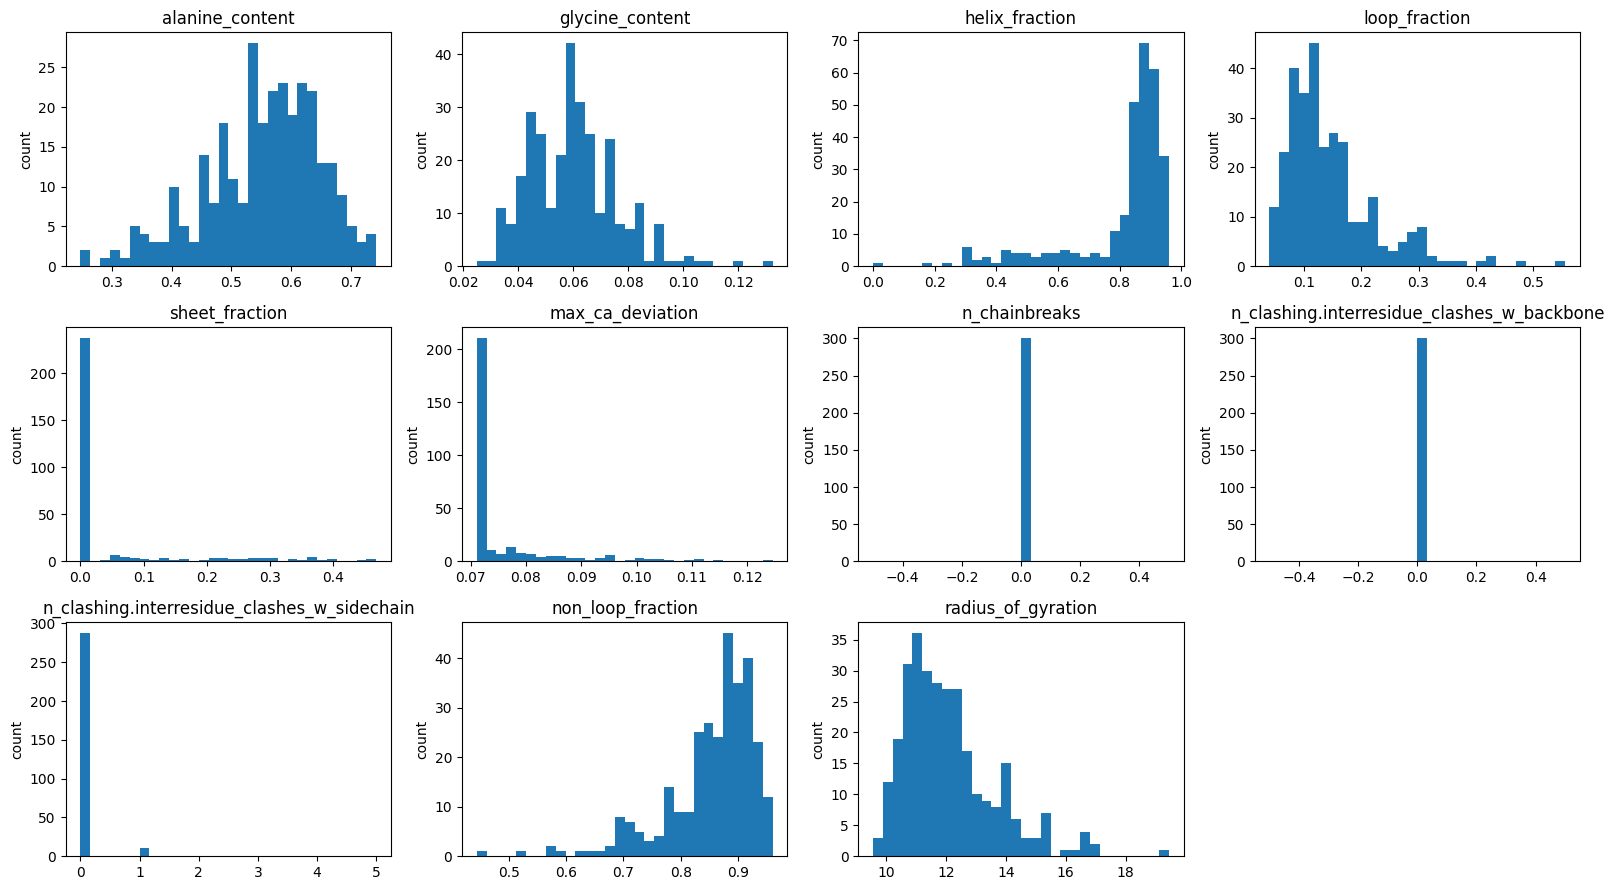

In [5]:
metrics = [
    "alanine_content",
    "glycine_content",
    "helix_fraction",
    "loop_fraction",
    "sheet_fraction",
    "max_ca_deviation",
    "n_chainbreaks",
    "n_clashing.interresidue_clashes_w_backbone",
    "n_clashing.interresidue_clashes_w_sidechain",
    "non_loop_fraction",
    "radius_of_gyration",
]

# Keep only columns that exist (safety)
metrics = [m for m in metrics if m in df.columns]

print("Plotting:", metrics)

n_metrics = len(metrics)
n_cols = 4
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

def plot_hist(ax, series, title):
    s = series.dropna()
    if s.empty:
        ax.set_title(f"{title} (no data)")
        ax.axis("off")
        return
    ax.hist(s, bins=30)
    ax.set_title(title)
    ax.set_ylabel("count")

for ax, col in zip(axes, metrics):
    plot_hist(ax, df[col], col)

# Turn off unused axes
for ax in axes[len(metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Optional: filter backbones by loop content

RFD3 backbones with too much loop / too little secondary structure tend to fold
unreliably downstream. Filtering them out here means MPNN + RF3 only run on the
backbones worth the (shared) GPU time. Passing designs are copied into a
`passing_loop_nonloop/` subfolder; MPNN picks them up automatically.

Skip this section to keep **all** backbones — MPNN falls back to the full set if no
backbone passes (e.g. at the tiny default of 4 backbones).

In [6]:
df_filt = df[
    (df["loop_fraction"] < 0.4) &
    (df["non_loop_fraction"] > 0.6)
].copy()

print(f"Total designs: {len(df)}")
print(f"Passing designs: {len(df_filt)}")
df_filt.head()

Total designs: 300
Passing designs: 295


,json_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,/dtu/blackhole/0e/213806/group_project/work/ex...,0.715596,2.783414,1.131739,-2.319902,-7.309885,-2.89432,14.249235,0.045872,0.920455,0.079545,0.073974,0,0,0,0.920455,109,4,11.501409,0.000
1,/dtu/blackhole/0e/213806/group_project/work/ex...,0.669725,0.839008,-2.041902,-0.755541,-7.309885,-2.89432,14.249235,0.036697,0.909091,0.090909,0.071092,0,0,0,0.909091,109,3,13.938260,0.000
2,/dtu/blackhole/0e/213806/group_project/work/ex...,0.559633,3.499528,-1.404865,-2.891588,-7.309885,-2.89432,14.249235,0.045872,0.886364,0.113636,0.102402,0,0,0,0.886364,109,4,11.915928,0.000
3,/dtu/blackhole/0e/213806/group_project/work/ex...,0.651376,2.524239,-0.289546,-2.572828,-7.309885,-2.89432,14.249235,0.073394,0.886364,0.113636,0.071092,0,0,0,0.886364,109,4,11.474293,0.000
4,/dtu/blackhole/0e/213806/group_project/work/ex...,0.605505,-0.300210,0.734890,-0.853268,-7.309885,-2.89432,14.249235,0.064220,0.715909,0.159091,0.071092,0,0,0,0.840909,109,5,15.293975,0.125


In [7]:
PATH_COL = "json_path"
filter_name = "passing_loop_nonloop"

filtered_dir = Path(diffusion_out_dir) / filter_name
filtered_dir.mkdir(parents=True, exist_ok=True)

def copy_design(json_path: str, dst_dir: Path) -> int:
    """Copy one design's JSON and its matching CIF/CIF.GZ (same stem) into dst_dir."""
    jp = Path(json_path)
    if not jp.exists():
        return 0
    copied = 0
    dst_json = dst_dir / jp.name
    if not dst_json.exists():
        shutil.copy2(jp, dst_json)
        copied += 1
    stem = jp.stem
    for cif in (jp.with_name(stem + ".cif"), jp.with_name(stem + ".cif.gz")):
        if cif.exists():
            dst_cif = dst_dir / cif.name
            if not dst_cif.exists():
                shutil.copy2(cif, dst_cif)
                copied += 1
    return copied

total_copied = missing = 0
unique_paths = df_filt[PATH_COL].dropna().unique()
for pth in unique_paths:
    if not isinstance(pth, str) or not os.path.exists(pth):
        print(f"[MISSING] {pth}")
        missing += 1
        continue
    total_copied += copy_design(pth, filtered_dir)

print(f"Passing designs: {len(unique_paths)}")
print(f"Copied files: {total_copied}")
print(f"Output folder: {filtered_dir}")

Passing designs: 295
Copied files: 590
Output folder: /dtu/blackhole/0e/213806/group_project/work/exp_04/diffusion_out/passing_loop_nonloop


## 2. ProteinMPNN — design sequences

ProteinMPNN writes amino-acid sequences onto each RFD3 backbone. We redesign the whole
binder chain (`A`) freely; nothing is fixed. We do **not** filter the MPNN output — every
sequence goes forward to RF3.

This builds one command per backbone and submits them as a single LSF **job array**.

In [ ]:
seed              = 42
batch_size        = 16     # sequences per backbone
number_of_batches = 1     # total sequences per backbone = batch_size * number_of_batches
chains_to_design  = "A"   # binder chain
ckpt = "/dtu/projects/dbl/foundry/ckpt/proteinmpnn_v_48_020.pt"
hotspot_ok_dir = str(WORK / "passing_hotspot_contacts")  

cmds = f"{cmds_dir}/mpnn.cmds"
#filtered = sorted(glob.glob(f"{diffusion_out_dir}/passing_loop_nonloop/*.cif.gz"))
filtered = sorted(glob.glob(f"{hotspot_ok_dir}/*.cif.gz"))
structures = filtered if filtered else sorted(glob.glob(f"{diffusion_out_dir}/*.cif.gz"))
print(f"Using {len(structures)} backbone(s) "
      + ("(loop-filtered)" if filtered else "(all backbones — no filter applied)"))
if not structures:
    raise SystemExit(f"No backbones (*.cif.gz) in {diffusion_out_dir} — run RFD3 first.")

with open(cmds, "w") as f:
    for structure in structures:
        bn = os.path.basename(structure).replace(".cif.gz", "")
        this_out = f"{mpnn_out_dir}/{bn}"
        os.makedirs(this_out, exist_ok=True)
        cmd = (f"mpnn --seed {seed} --structure_path \"{structure}\" "
               f"--out_directory \"{this_out}\" --batch_size {batch_size} "
               f"--number_of_batches {number_of_batches} --model_type protein_mpnn "
               f"--checkpoint_path \"{ckpt}\" --is_legacy_weights True "
               f"--designed_chains \"{chains_to_design}\"")
        f.write(cmd + "\n")

n_tasks = sum(1 for _ in open(cmds))
sub_script = jupyter_utils.make_sub_script(
    cmds, n_task=n_tasks, group_size=10, mem="10G", queue="c27666",
    job_name="mpnn", cores=4, time_limit="2:00",
    env="/dtu/blackhole/00/c27666/miniforge3/envs/protein-design",
)
print(f"\n{n_tasks} MPNN command(s).")
print("Submit:\n  bsub < " + sub_script)

Using 6 backbone(s) (loop-filtered)
Submit script written: /dtu/blackhole/0e/213806/group_project/work/exp_04/cmds/mpnn.sh

6 MPNN command(s).
Submit:
  bsub < /dtu/blackhole/0e/213806/group_project/work/exp_04/cmds/mpnn.sh


## 3. RF3 - fold and score each binder

RF3 folds the binder sequence together with the target you can have Zn/Ca
cofactors. One RF3 job
per MPNN sequence.

First we turn every MPNN sequence into an RF3 input JSON from the bundled template.

### Build RF3 input JSONs (no filtering — all sequences kept)

In [ ]:
rf3_template_path = str(REPO_ROOT / "inputs" / "rf3_template.json")
rf3_json_dir = Path(configs_dir) / "rf3"
rf3_json_dir.mkdir(parents=True, exist_ok=True)

with open(rf3_template_path) as f:
    template = json.load(f)

# Rewrite the target structure path to an absolute path inside THIS clone,
# so RF3 finds it no matter where the job runs from.
for comp in template["components"]:
    if isinstance(comp, dict) and "path" in comp:
        comp["path"] = str((REPO_ROOT / comp["path"]).resolve())

# Locate the binder component (chain A, has a 'seq' we overwrite)
binder_idx = next(i for i, c in enumerate(template["components"])
                  if isinstance(c, dict) and c.get("chain_id") == "A" and "seq" in c)

# Match the new mpnn FASTA header: >{name}_b{batch_idx}_d{design_idx}, sequence_recovery=...
DESIGN_RE = re.compile(r"_b(\d+)_d(\d+)")

def parse_fasta(path):
    header, chunks = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(chunks)
                header, chunks = line[1:], []
            else:
                chunks.append(line)
        if header is not None:
            yield header, "".join(chunks)

# New mpnn writes FASTAs directly into the per-backbone output folder (no seqs/ subdir)
fa_files = sorted(glob.glob(os.path.join(mpnn_out_dir, "**", "*.fa"),
                            recursive=True))
if not fa_files:
    raise SystemExit(f"No MPNN FASTAs under {mpnn_out_dir} — run MPNN first.")

written = 0
for fa in fa_files:
    model_dir = os.path.basename(os.path.dirname(fa))   # backbone name from parent dir
    for header, seq in parse_fasta(fa):
        m = DESIGN_RE.search(header)
        if not m:
            continue
        batch_idx  = int(m.group(1))
        design_idx = int(m.group(2))
        chain_a = seq.split(":", 1)[0]   # binder is the first (and only) designed chain
        j = deepcopy(template)
        j["components"][binder_idx]["seq"] = chain_a
        name = f"{model_dir}__b{batch_idx}_d{design_idx}"
        j["name"] = name
        with open(rf3_json_dir / f"{name}.json", "w") as out:
            json.dump(j, out, indent=2)
        written += 1
        
print(f"Wrote {written} RF3 input JSONs -> {rf3_json_dir}")

Wrote 96 RF3 input JSONs -> /dtu/blackhole/0e/213806/group_project/work/exp_04/configs/rf3


### Write the RF3 submit script (job array)

In [ ]:
queue       = "c27666"
job_name    = "rf3"
time_limit  = "2:00"
mem         = "16GB"
gpu_spec    = "num=1:mode=exclusive_process"
cores       = 4
group_size  = 20                    # RF3 folds per array task
rf3_release = "/dtu/projects/dbl/rf3/release"
ckpt_path   = "/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt"
num_steps   = 50

json_files = sorted(Path(rf3_json_dir).glob("*.json"))
if not json_files:
    raise SystemExit(f"No RF3 JSONs in {rf3_json_dir}")

cmds_path = Path(cmds_dir) / "rf3.cmds"
lines = []
for jf in json_files:
    out_dir = Path(rf3_out_dir) / jf.stem
    lines.append(
        f"python {REPO_ROOT}/lib/rf3_wrapper.py fold inference_engine=rf3 inputs={jf} out_dir={out_dir} "
        f"ckpt_path={ckpt_path} num_steps={num_steps} "
        f"annotate_b_factor_with_plddt=True early_stopping_plddt_threshold=0"
    )
cmds_path.write_text("\n".join(lines) + "\n")

n_arrays = math.ceil(len(lines) / group_size)
script = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J {job_name}[1-{n_arrays}]
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J_%I.out
#BSUB -e {logs_dir}/%J_%I.err

mkdir -p {logs_dir}
module load cuda/12.4
# RF3 uses its own dedicated environment (rf3-env) from the release directory;
# the protein-design env is used for RFD3 and MPNN.
source {rf3_release}/activate_env.sh
export DISABLE_CUEQUIVARIANCE=true   # same workaround as RFD3

CMDS_FILE={cmds_path}
GROUP_SIZE={group_size}
START=$(( (LSB_JOBINDEX - 1) * GROUP_SIZE ))
END=$(( START + GROUP_SIZE ))
i=0
while IFS= read -r cmd; do
    if [ "$i" -ge "$START" ] && [ "$i" -lt "$END" ]; then
        echo "Running: $cmd"
        eval "$cmd"
    fi
    i=$((i+1))
done < "$CMDS_FILE"
echo "Done at $(date)"
"""

sub = Path(submit_dir) / "rf3.sh"
sub.write_text(script)
print(f"{len(lines)} RF3 folds in {n_arrays} array task(s).")
print("Submit:\n  bsub < " + str(sub))

96 RF3 folds in 5 array task(s).
Submit:
  bsub < /dtu/blackhole/0e/213806/group_project/work/exp_04/submit/rf3.sh


### Score and plot RF3 results

Run after the RF3 jobs finish. Key metrics per design:

- **`best_binder_plddt`** — confidence of the binder fold (0–1; higher is better).
- **`AF_best_min_pae`** — interface PAE between binder and target (Å; **lower** is better).
- **`AF_ipsae_at_best`** — interface ipSAE (0–1; **higher** = better-defined interface).

In [5]:
# Chain IDs in RF3 output:
#   A_1 = binder  |  B_1 = MMP9 protein  |  C_1-G_1 = ZN/CA metal ions
BINDER   = "A_1"
TARGET_F = "B_1"   # binder <-> MMP9 (primary interface)
TARGET_G = "B_1"   # same single target chain

OUT_CSV = f"{scores_dir}/rf3_gathered_metrics.csv"

df_rf3 = gather_rf3_metrics(
    parent=rf3_out_dir,
    binder=BINDER,
    target_f=TARGET_F,
    target_g=TARGET_G,
    out_csv=OUT_CSV,
)
print(f"{len(df_rf3)} designs scored")
df_rf3.head()

0 designs scored


""


In [ ]:
# -- Single-experiment scatter: PAE vs pLDDT, coloured by ipSAE ----------------
# Thresholds -- shared across all filtering and selection cells
PAE_CUT   = 5.0    # AF_best_min_pae  < PAE_CUT   (A)
PLDDT_CUT = 0.85   # best_binder_plddt > PLDDT_CUT (0-1)
IPSAE_CUT = 0.80   # AF_ipsae_at_best  > IPSAE_CUT (0-1)

df = df_rf3
x   = df['AF_best_min_pae'].to_numpy(float)
y   = df['best_binder_plddt'].to_numpy(float)
c   = df['AF_ipsae_at_best'].to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 13,
    "axes.linewidth": 1.1, "figure.dpi": 150,
})
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(x[mask], y[mask],
                c=c[mask], s=20, alpha=0.85, linewidths=0,
                cmap='viridis', vmin=0, vmax=1)

ax.axvline(PAE_CUT,   color='k', lw=0.9, ls='--', alpha=0.6)
ax.axhline(PLDDT_CUT, color='k', lw=0.9, ls='--', alpha=0.6)
ax.set_xlabel('Interface PAE (A)  [lower = better]')
ax.set_ylabel('Binder pLDDT  [higher = better]')
ax.set_title(f'RF3 validation - PAE vs pLDDT  (n={len(df)})')
ax.set_xlim(left=0)
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.5)
fig.colorbar(sc, ax=ax).set_label('ipSAE  [higher = better]')
fig.tight_layout()
plt.show()

In [ ]:
# -- Binder-MMP9: PAE vs ipSAE, coloured by ipSAE -----------------------------
x   = df['AF_best_min_pae'].to_numpy(float)
y   = df['AF_ipsae_at_best'].to_numpy(float)
c   = df['AF_ipsae_at_best'].to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(x[mask], y[mask],
                c=c[mask], s=20, alpha=0.85, linewidths=0,
                cmap='viridis', vmin=0, vmax=1)
ax.axvline(PAE_CUT,   color='k', lw=0.9, ls='--', alpha=0.6)
ax.axhline(IPSAE_CUT, color='k', lw=0.9, ls='--', alpha=0.6)
ax.set_xlabel('min-PAE (A)  [lower = better]')
ax.set_ylabel('inter-chain ipSAE  [higher = better]')
ax.set_title('Binder-MMP9')
ax.set_xlim(left=0)
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.5)
fig.colorbar(sc, ax=ax).set_label('ipSAE')
fig.tight_layout()
plt.show()

In [ ]:
# -- Two-panel: left = PAE vs pLDDT, right = ipSAE vs pLDDT --------------------
x_pae   = df['AF_best_min_pae'].to_numpy(float)
x_ipsae = df['AF_ipsae_at_best'].to_numpy(float)
y_plddt = df['best_binder_plddt'].to_numpy(float)

mask = np.isfinite(x_pae) & np.isfinite(x_ipsae) & np.isfinite(y_plddt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, x_vals, xlabel, cutval in [
    (axes[0], x_pae,   'Interface PAE (A)  [lower = better]', PAE_CUT),
    (axes[1], x_ipsae, 'ipSAE  [higher = better]',            IPSAE_CUT),
]:
    sc = ax.scatter(x_vals[mask], y_plddt[mask],
                    c=x_ipsae[mask], s=20, alpha=0.85, linewidths=0,
                    cmap='viridis', vmin=0, vmax=1)
    ax.axhline(PLDDT_CUT, color='k', lw=0.9, ls='--', alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.5)
    fig.colorbar(sc, ax=ax).set_label('ipSAE')

axes[0].axvline(PAE_CUT,   color='k', lw=0.9, ls='--', alpha=0.6)
axes[1].axvline(IPSAE_CUT, color='k', lw=0.9, ls='--', alpha=0.6)
axes[0].set_xlim(left=0)
axes[1].set_xlim(0, 1.0)
axes[0].set_ylabel('Binder pLDDT  [higher = better]')
axes[0].set_title('PAE vs pLDDT')
axes[1].set_title('ipSAE vs pLDDT')

fig.suptitle(f'RF3 validation - {len(df)} designs', fontsize=13)
fig.tight_layout()
plt.show()

## 4. Collect your best binders

Designs passing all three thresholds are saved to `best_binders/` (their RF3 input JSON
and a scored CSV). These are your candidates to inspect in PyMOL/ChimeraX.

In [ ]:
# -- Collect best binders: pass all three thresholds -> best_binders/ ---------
import gzip as _gz

pass_mask = (
    (df_rf3['AF_best_min_pae']   < PAE_CUT) &
    (df_rf3['best_binder_plddt'] > PLDDT_CUT) &
    (df_rf3['AF_ipsae_at_best']  > IPSAE_CUT)
)
df_best = df_rf3[pass_mask].copy()
print(f"{len(df_best)} / {len(df_rf3)} designs pass thresholds "
      f"(PAE<{PAE_CUT}, pLDDT>{PLDDT_CUT}, ipSAE>{IPSAE_CUT})")

best_dir = Path(best_binders_dir)
best_dir.mkdir(parents=True, exist_ok=True)

copied_cif, copied_json, missing = 0, 0, []
for _, row in df_best.iterrows():
    did  = row['design_id']
    bidx = int(row['best_batch_idx'])
    sf   = Path(row['score_file'])

    cif_src  = sf.parent / f"{did}_model_{bidx}.cif.gz"     # best RF3 model
    json_src = Path(rf3_json_dir) / f"{did}.json"            # the RF3 input

    dst_cif = best_dir / f"{did}_model_{bidx}.cif"          # decompressed
    if cif_src.exists():
        with _gz.open(cif_src, "rb") as gz_in, open(dst_cif, "wb") as out:
            out.write(gz_in.read())
        copied_cif += 1
    else:
        missing.append(str(cif_src))

    dst_json = best_dir / f"{did}.json"
    if json_src.exists():
        shutil.copy2(json_src, dst_json)
        copied_json += 1
    else:
        missing.append(str(json_src))

print(f"Copied {copied_cif} CIF + {copied_json} JSON -> {best_dir}")
if missing:
    print(f"Missing {len(missing)} source file(s); first few:")
    for m in missing[:10]:
        print("  ", m)

best_csv = best_dir / "best_binders_metrics.csv"
df_best.to_csv(best_csv, index=False)
print(f"Metrics -> {best_csv}")
df_best[["design_id", "AF_best_min_pae", "best_binder_plddt", "AF_ipsae_at_best"]]